# ADP Offline Training — Approximate Policy Iteration (API)

We train a **time-dependent strictly linear Value Function Approximation (VFA)**:
$$\hat{V}_t(x_t;\, \boldsymbol{w}_t, b_t) = \boldsymbol{w}_t^\top \phi(x_t) + b_t$$

using **Approximate Policy Iteration (API)** with $N_{\text{outer}} = 12$ iterations,
$N_{\text{samples}} = 35$ trajectories per forward pass, and $N_{\text{inner}} = 5$ policy-evaluation sweeps:

1. **Forward pass** — simulate the current greedy policy over 35 randomly drawn historical
   scenarios with randomised initial physical states to cover the operational state space.
2. **Inner loop** ($N_{\text{inner}} = 5$ backward sweeps) — for $t = T{-}1,\ldots,0$,
   solve a 1-step MILP under the certainty-equivalence principle to obtain Bellman targets
   $V^*(x_{n,t})$, fit $(\boldsymbol{w}_t, b_t)$ by Ridge regression with intercept,
   and update via **Polyak averaging**:
   $\boldsymbol{w}_t \leftarrow (1{-}\beta)\,\boldsymbol{w}_t + \beta\,\hat{\boldsymbol{w}}_t$
   with $\beta = 0.25$.
3. **Export** — save all weights and intercepts to `output/adp_weights.json`.

### Feature vector $\phi(x_t) \in \mathbb{R}^{10}$ — normalised to $[-1,\,1]$

| Index | Feature | Formula | Baseline | Scale | Rationale |
|-------|---------|---------|----------|-------|-----------|
| 0 | $T_1$ | $(T_1 - 22)/8$ | 22 °C | 8 °C | Comfort target; range $[18,26]$ maps to $[-0.5, 0.5]$ |
| 1 | $T_2$ | $(T_2 - 22)/8$ | 22 °C | 8 °C | Same as $T_1$ |
| 2 | $H$ | $(H - 40)/40$ | 40 % | 40 % | Nominal humidity; override at 70 % |
| 3 | $\lambda_t$ | $\lambda_t / 10$ | — | 10 €/kWh | Price range $[0,12]$ maps to $[0,1.2]$ |
| 4 | $\lambda_{t-1}$ | $\lambda_{t-1} / 10$ | — | 10 €/kWh | Serial-correlation signal |
| 5 | $\text{occ}_1$ | $(\text{occ}_1 - 30)/30$ | 30 pax | 30 | Centred at midpoint of $[25,35]$ |
| 6 | $\text{occ}_2$ | $(\text{occ}_2 - 20)/20$ | 20 pax | 20 | Centred at midpoint of $[15,25]$ |
| 7 | $c$ | $c/3$ | — | 3 | Inertia counter; $c \in \{0,1,2\}$ maps to $[0, 2/3]$ |
| 8 | $\text{pen}_1$ | $\max(0,\,19.5 - T_1)/5$ | — | 5 °C | Hockey-stick: encodes asymmetric risk near $T_{\min}=18\,°$C |
| 9 | $\text{pen}_2$ | $\max(0,\,19.5 - T_2)/5$ | — | 5 °C | Same for room 2 |

The Ridge intercept $b_t$ is fitted with `fit_intercept=True` and stored as `eta[t][10]`,
giving an 11-vector per timestep.

### Certainty-equivalence principle

Because $\hat{V}$ is strictly linear in $x$ and the state dynamics are linear in the exogenous
variables $(\text{occ}_1, \text{occ}_2, \lambda)$, Jensen's inequality holds with equality:
$$\mathbb{E}\bigl[\hat{V}_{t+1}(x_{t+1})\bigr] = \hat{V}_{t+1}\!\bigl(\mathbb{E}[x_{t+1}]\bigr).$$
Substituting expected next-period values converts the stochastic look-ahead into a deterministic
**single-scenario MILP** — one binary variable, linear objective, linear constraints.

The hockey-stick features $\text{pen}_1, \text{pen}_2$ involve a $\max(\cdot,\cdot)$ operator.
Their expected values are handled by auxiliary Pyomo variables with linear lower-bound constraints,
preserving the MILP structure exactly.

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
import pyomo.environ as pyo
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))
import v2_SystemCharacteristics as sc

raw = sc.get_fixed_data()

params = {
    'P_max'    : raw['heating_max_power'],
    'P_vent'   : raw['ventilation_power'],
    'T_low'    : raw['temp_min_comfort_threshold'],
    'T_ok'     : raw['temp_OK_threshold'],
    'T_high'   : raw['temp_max_comfort_threshold'],
    'H_high'   : raw['humidity_threshold'],
    'zeta_exch': raw['heat_exchange_coeff'],
    'zeta_loss': raw['thermal_loss_coeff'],
    'zeta_conv': raw['heating_efficiency_coeff'],
    'zeta_cool': raw['heat_vent_coeff'],
    'zeta_occ' : raw['heat_occupancy_coeff'],
    'eta_occ'  : raw['humidity_occupancy_coeff'],
    'eta_vent' : raw['humidity_vent_coeff'],
    'T_out'    : raw['outdoor_temperature'],
}

T_INIT = float(raw['T1'])   # 21.0 °C
H_INIT = float(raw['H'])    # 40.0 %
T      = 10
N_FEAT = 9

print("System parameters loaded.")
print(f"  T_low={params['T_low']} | T_ok={params['T_ok']} | T_high={params['T_high']} | H_high={params['H_high']}")
print(f"  P_max={params['P_max']} kW | P_vent={params['P_vent']} kW")

System parameters loaded.
  T_low=18.0 | T_ok=22.0 | T_high=26.0 | H_high=70.0
  P_max=3.0 kW | P_vent=2.0 kW


In [2]:
price_df = pd.read_csv('v2_PriceData.csv', header=0)
occ1_df  = pd.read_csv('OccupancyRoom1.csv', header=0)
occ2_df  = pd.read_csv('OccupancyRoom2.csv', header=0)

# v2_PriceData.csv: col0 = previous price, cols '1'..'10' = price at t=0..9
# OccupancyRoomX.csv: cols '0'..'9' = occupancy at t=0..9
price_cols = [str(i) for i in range(1, 11)]
occ_cols   = [str(i) for i in range(10)]

prices_all  = price_df[price_cols].values.astype(float)   # (N, 10)
prev_prices = price_df.iloc[:, 0].values.astype(float)    # (N,)
occ1_all    = occ1_df[occ_cols].values.astype(float)      # (N, 10)
occ2_all    = occ2_df[occ_cols].values.astype(float)      # (N, 10)

N = len(prices_all)
print(f"Loaded {N} days of historical data.")
print(f"  Price range: [{prices_all.min():.2f}, {prices_all.max():.2f}] euro/kWh")
print(f"  Occ1  range: [{occ1_all.min():.1f}, {occ1_all.max():.1f}] persons")
print(f"  Occ2  range: [{occ2_all.min():.1f}, {occ2_all.max():.1f}] persons")

Loaded 100 days of historical data.
  Price range: [0.00, 12.00] euro/kWh
  Occ1  range: [20.5, 47.5] persons
  Occ2  range: [14.1, 30.0] persons


In [ ]:
N_FEAT = 12  # explicit features; Ridge intercept is stored separately as eta[12]

# Expected next-period exogenous midpoints (certainty-equivalence substitution).
_E_PRICE_NEXT =  5.0   # midpoint of Uniform(2, 8)
_E_OCC1_NEXT  = 30.0   # midpoint of Uniform(25, 35)
_E_OCC2_NEXT  = 20.0   # midpoint of Uniform(15, 25)


def phi(state: dict) -> np.ndarray:
    """
    Feature mapping phi(x_t) in R^12, normalised to [-1, 1] where applicable.

    The Ridge intercept is fitted separately (fit_intercept=True) and stored
    as eta[t][12], preserving the strict linearity required for the
    Certainty-Equivalence property:  E_w[phi(f(x,u,w))] = phi(f(x,u,E[w])).

    MUST match ADP_policy_14.py._phi() exactly.

      idx  feature          formula                              baseline  scale
       0   T1               (T1   - 22) / 8                     22 °C     8 °C
       1   T2               (T2   - 22) / 8                     22 °C     8 °C
       2   H                (H    - 40) / 40                     40 %      40 %
       3   price             price / 10                          0         10 €/kWh
       4   price_prev        price_prev / 10                     0         10 €/kWh
       5   occ1             (occ1 - 30) / 30                     30 pax    30
       6   occ2             (occ2 - 20) / 20                     20 pax    20
       7   c                 c / 3                               0         3
       8   pen1              max(0, 22.0 - T1) / 3               —         3 °C
       9   pen2              max(0, 22.0 - T2) / 3               —         3 °C
      10   price × pen1      (price/10) * max(0,22.0-T1)/3       —         —
      11   price × pen2      (price/10) * max(0,22.0-T2)/3       —         —

    Threshold set at T_ok=22°C (comfort target) so the penalty activates as
    soon as temperatures drop below the comfort level, giving the VFA an
    early-warning gradient well before the hard constraint T_low=18°C.

    Features 10 and 11 capture the interaction "cold rooms during high-price
    periods are disproportionately costly" — a nonlinearity that the base linear
    VFA cannot express but that is critical for avoiding temperature cascades.
    """
    T1         = float(state['T1'])
    T2         = float(state['T2'])
    H          = float(state.get('H', 0.0))
    price      = float(state['price'])
    price_prev = float(state.get('price_previous', state['price']))
    occ1       = float(state.get('occ1', 0.0))
    occ2       = float(state.get('occ2', 0.0))
    c          = float(state.get('c', 0))
    pen1       = max(0.0, 22.0 - T1) / 3.0
    pen2       = max(0.0, 22.0 - T2) / 3.0
    p_norm     = price / 10.0
    return np.array([
        (T1         - 22.0) / 8.0,
        (T2         - 22.0) / 8.0,
        (H          - 40.0) / 40.0,
         p_norm,
         price_prev          / 10.0,
        (occ1       - 30.0) / 30.0,
        (occ2       - 20.0) / 20.0,
         c                  /  3.0,
         pen1,
         pen2,
         p_norm * pen1,
         p_norm * pen2,
    ], dtype=float)


# Sanity check
s_test = {'T1': 22.0, 'T2': 20.0, 'H': 55.0, 'c': 1,
          'price': 8.0, 'price_previous': 3.0, 'occ1': 35.0, 'occ2': 15.0}
print("phi(test) =", np.round(phi(s_test), 4))
s_cold = {'T1': 18.0, 'T2': 19.0, 'H': 40.0, 'c': 0,
          'price': 5.0, 'price_previous': 5.0, 'occ1': 30.0, 'occ2': 20.0}
print("phi(cold) =", np.round(phi(s_cold), 4), " ← pen1,pen2 and cross-products should be >0")
s_init = {'T1': 21.0, 'T2': 21.0, 'H': 40.0, 'c': 0,
          'price': 5.0, 'price_previous': 5.0, 'occ1': 30.0, 'occ2': 20.0}
print("phi(init) =", np.round(phi(s_init), 4), " ← pen=0.333, cross=0.167 at T=21,price=5")
print(f"N_FEAT={N_FEAT}  (intercept stored at eta[12] — fitted by Ridge separately)")
print(f"_E_PRICE={_E_PRICE_NEXT}  _E_OCC1={_E_OCC1_NEXT}  _E_OCC2={_E_OCC2_NEXT}")


In [4]:
def apply_dynamics(state, decisions):
    """One-step transition — mirrors Task6_Environment.apply_dynamics exactly."""
    p  = params
    t  = int(state['current_time'])
    p1 = float(decisions['HeatPowerRoom1'])
    p2 = float(decisions['HeatPowerRoom2'])
    v  = int(float(decisions['VentilationON']) > 0.5)
    H  = float(state.get('H', 0.0))
    c  = int(state.get('c', 0))

    # Overrule controllers (mandatory)
    if c > 0:                 v  = 1
    if H >= p['H_high']:      v  = 1
    if state.get('y_low_1'):  p1 = p['P_max']
    if state.get('y_low_2'):  p2 = p['P_max']
    if state.get('y_high_1'): p1 = 0.0
    if state.get('y_high_2'): p2 = 0.0

    step_cost = float(state['price']) * (p1 + p2 + p['P_vent'] * v)

    T_out = float(p['T_out'][min(t, 9)])
    T1    = float(state['T1']);  T2   = float(state['T2'])
    occ1  = float(state.get('occ1', 0.0));  occ2 = float(state.get('occ2', 0.0))

    T1_n = (T1 + p['zeta_exch']*(T2 - T1) + p['zeta_loss']*(T_out - T1)
            + p['zeta_conv']*p1 - p['zeta_cool']*v + p['zeta_occ']*occ1)
    T2_n = (T2 + p['zeta_exch']*(T1 - T2) + p['zeta_loss']*(T_out - T2)
            + p['zeta_conv']*p2 - p['zeta_cool']*v + p['zeta_occ']*occ2)
    H_n  = max(0.0, H + p['eta_occ']*(occ1 + occ2) - p['eta_vent']*v)
    c_n  = (2 if c == 0 else max(0, c - 1)) if v == 1 else 0

    y_lo1 = (1 if T1_n < p['T_low'] else
             (0 if T1_n >= p['T_ok'] else int(state.get('y_low_1', 0))))
    y_lo2 = (1 if T2_n < p['T_low'] else
             (0 if T2_n >= p['T_ok'] else int(state.get('y_low_2', 0))))
    y_hi1 = 1 if T1_n > p['T_high'] else 0
    y_hi2 = 1 if T2_n > p['T_high'] else 0

    return {
        'T1': T1_n, 'T2': T2_n, 'H': H_n, 'c': c_n,
        'y_low_1': y_lo1, 'y_low_2': y_lo2,
        'y_high_1': y_hi1, 'y_high_2': y_hi2,
        'occ1': occ1, 'occ2': occ2,
        'price': float(state['price']),
        'price_previous': float(state['price']),
        'current_time': t + 1,
    }, step_cost


def heuristic_policy(state: dict) -> dict:
    """
    Reactive heuristic for the first-iteration forward pass.

    Heats room r when its temperature is below T_ok − 1 °C = 21 °C,
    ensuring the forward pass generates states near the lower comfort
    boundary where the VFA must be accurate.  Ventilates when the
    inertia counter requires it (c > 0), the humidity override is active
    (H ≥ H_high), or humidity is moderately elevated (H > 55 %).
    """
    p  = params
    T1 = float(state['T1']);  T2 = float(state['T2'])
    H  = float(state.get('H', 0.0));  c = int(state.get('c', 0))

    v = 1 if (c > 0 or H >= p['H_high']) else int(H > 55.0)

    def heat_power(T_r, y_lo, y_hi):
        if y_hi: return 0.0
        if y_lo: return p['P_max']
        return p['P_max'] if T_r < (p['T_ok'] - 1.0) else 0.0

    return {
        'HeatPowerRoom1': heat_power(T1, state.get('y_low_1', 0), state.get('y_high_1', 0)),
        'HeatPowerRoom2': heat_power(T2, state.get('y_low_2', 0), state.get('y_high_2', 0)),
        'VentilationON' : v,
    }

print("apply_dynamics and heuristic_policy defined.")

apply_dynamics and heuristic_policy defined.


## Step 1 — Forward Pass

Simulate the current policy over all $N$ historical scenarios.
Each scenario uses the fixed initial physical state $(T^{\mathrm{init}}, H^{\mathrm{init}})$
with the realised historical prices and occupancies.
The first outer iteration uses the reactive heuristic; subsequent iterations use
the current greedy ADP policy.

In [5]:
N_SAMPLES = 50   # trajectories per forward pass


def run_forward_pass(policy_fn) -> list:
    """
    Simulate policy_fn over N_SAMPLES randomly drawn trajectories.

    Design choices for training diversity and OLS identifiability:

    1. Random day selection from the N=100 historical CSV scenarios (with
       replacement) provides diverse price/occupancy sequences without
       requiring a stochastic process model.

    2. Randomised initial physical state (T1, T2 in [17.5, 23.5] °C;
       H in [30, 60] %) ensures the regression sees states well below the
       19.5 °C hockey-stick threshold, where the penalty VFA must be accurate.

    3. Exploratory initial discrete state: c drawn from {0, 1, 2} and
       y_low_1/y_low_2 drawn from {0, 1} via np.random.choice.
       CRITICAL: deterministic initialisation (c=0, y_low=0 for all n)
       creates a zero-variance column in the feature matrix at t=0,
       which destroys the regression gradient for the c feature and
       produces large erratic coefficients.  Random initialisation
       eliminates this degeneracy while staying within the physically
       reachable state space.

    Returns
    -------
    states_out : list[list[dict]]
        states_out[t][n] is the state dict at time t for trajectory n.
    """
    states_out  = [[None] * N_SAMPLES for _ in range(T)]
    day_indices = np.random.choice(N, N_SAMPLES, replace=True)

    for n, di in enumerate(day_indices):
        T1_0    = np.random.uniform(17.5, 23.5)
        T2_0    = np.random.uniform(17.5, 23.5)
        H_0     = np.random.uniform(30.0, 60.0)
        c_0     = int(np.random.choice([0, 1, 2]))
        y_lo1_0 = int(np.random.choice([0, 1]))
        y_lo2_0 = int(np.random.choice([0, 1]))

        state = {
            'T1': T1_0, 'T2': T2_0, 'H': H_0,
            'c': c_0, 'y_low_1': y_lo1_0, 'y_low_2': y_lo2_0,
            'y_high_1': 0, 'y_high_2': 0,
            'occ1'          : float(occ1_all[di, 0]),
            'occ2'          : float(occ2_all[di, 0]),
            'price'         : float(prices_all[di, 0]),
            'price_previous': float(prev_prices[di]),
            'current_time'  : 0,
        }
        for t in range(T):
            state['price']          = float(prices_all[di, t])
            state['price_previous'] = (float(prices_all[di, t - 1]) if t > 0
                                       else float(prev_prices[di]))
            state['occ1']           = float(occ1_all[di, t])
            state['occ2']           = float(occ2_all[di, t])
            state['current_time']   = t
            states_out[t][n] = dict(state)
            state, _ = apply_dynamics(state, policy_fn(state))

    return states_out


print(f"run_forward_pass: N_SAMPLES={N_SAMPLES}, T1/T2 in [17.5, 23.5] °C, H in [30,60] %.")
print("  Exploratory init: c ~ {0,1,2}, y_low ~ {0,1} — ensures OLS identifiability at t=0.")

run_forward_pass: N_SAMPLES=50, T1/T2 in [17.5, 23.5] °C, H in [30,60] %.
  Exploratory init: c ~ {0,1,2}, y_low ~ {0,1} — ensures OLS identifiability at t=0.


## Step 2 — Backward Pass + Ridge Regression

For each inner sweep, iterate backwards over $t = T{-}1, \ldots, 0$:

$$V^*(x_{n,t}) = \min_{p_1,\,p_2,\,v}\Bigl\{\lambda_{n,t}(p_1+p_2+P_{\text{vent}}\,v) + \hat{V}_{t+1}\!\bigl(\mathbb{E}[x_{t+1}(p_1,p_2,v)]\bigr)\Bigr\}$$

where $\mathbb{E}[x_{t+1}]$ is obtained by substituting expected next-period exogenous values into the deterministic dynamics — a valid substitution because both $\hat{V}_{t+1}$ and the dynamics are strictly linear in $(\text{occ}_1, \text{occ}_2, \lambda)$.

Then fit $\hat{\eta}_t$ by **Ridge regression** on $(\Phi_t,\, V^*_t)$:
$$\hat{\eta}_t = \arg\min_\eta \bigl\|\Phi_t\,\eta - V^*_t\bigr\|^2 + \alpha\|\eta\|^2, \quad \alpha = 1.$$

**Within-pass bootstrap**: the just-fitted $\hat{\eta}_{t+1}$ is used immediately for step $t$, propagating information backward within each sweep.

**Terminal condition**: $\hat{V}_T \equiv 0$ (zero continuation value after the last period).

In [ ]:
BIG_M = 1_000


def solve_1step(state: dict, eta_next: np.ndarray,
                return_action: bool = False):
    """
    One-step linear MILP under the certainty-equivalence principle.

    Mathematical justification
    --------------------------
    VFA hat{V}_{t+1}(x) = w^T phi(x) + b is strictly linear in x.
    Dynamics f(x, u, w) are linear in (occ1, occ2, lambda).  By linearity:
        E_w[hat{V}(f(x, u, w))] = hat{V}(f(x, u, E[w])).
    Substituting (_E_OCC1_NEXT, _E_OCC2_NEXT, _E_PRICE_NEXT) for unknown
    next-period exogenous variables yields a single-scenario MILP with one
    binary variable, a linear objective, and linear constraints.

    Hockey-stick features pen1, pen2 = max(0, 22.0 - T_r_next) / 3 are
    encoded as auxiliary Pyomo variables (epigraph formulation) with:
      lower bound 0  — the max(.,.) floor
      upper bound 30 — corresponds to T_r_next = 22 - 30 = -8 °C, which is
                       physically impossible given T_out in [-3,3] °C and
                       thermal dynamics.  Physical worst case: pen ≈ (22-2)/3 ≈ 6.7.

    Cross-product features 10/11: (E[price_next]/10) * (pen_x/3).
    Since E[price_next] is a constant (CE substitution), these terms are linear
    in pen_x and preserve the MILP structure. They capture the interaction
    "cold rooms during high-price periods cost disproportionately more."

    Parameters
    ----------
    state        : current state dict
    eta_next     : weight vector for t+1  (length N_FEAT+1=13; eta_next[12]=intercept)
    return_action: True  → return optimal decision dict
                   False → return Bellman target scalar for regression
    """
    p      = params
    P_max  = p['P_max']
    t      = int(state.get('current_time', 0))
    T_out  = float(p['T_out'][min(t, 9)])
    T1     = float(state['T1'])
    T2     = float(state['T2'])
    H      = float(state.get('H', 0.0))
    c      = int(state.get('c', 0))
    occ1   = float(state.get('occ1', 0.0))
    occ2   = float(state.get('occ2', 0.0))
    price  = float(state['price'])
    eta    = eta_next

    m = pyo.ConcreteModel()

    # Decision variables
    m.p1  = pyo.Var(bounds=(0, P_max))
    m.p2  = pyo.Var(bounds=(0, P_max))
    m.v   = pyo.Var(domain=pyo.Binary)

    # Post-decision state variables (auxiliary, linear in decisions)
    m.T1x = pyo.Var()
    m.T2x = pyo.Var()
    m.Hx  = pyo.Var()

    # Thermal and humidity dynamics using realised current occupancy
    m.dT1 = pyo.Constraint(expr=
        m.T1x == T1 + p['zeta_exch']*(T2 - T1) + p['zeta_loss']*(T_out - T1)
               + p['zeta_conv']*m.p1 - p['zeta_cool']*m.v + p['zeta_occ']*occ1)
    m.dT2 = pyo.Constraint(expr=
        m.T2x == T2 + p['zeta_exch']*(T1 - T2) + p['zeta_loss']*(T_out - T2)
               + p['zeta_conv']*m.p2 - p['zeta_cool']*m.v + p['zeta_occ']*occ2)
    m.dH  = pyo.Constraint(expr=
        m.Hx  == H + p['eta_occ']*(occ1 + occ2) - p['eta_vent']*m.v)

    # Ventilation inertia counter: normalised feature c_next/3, linear in v.
    if   c == 0: c_next_norm = (2.0 / 3.0) * m.v
    elif c == 1: c_next_norm = 0.0
    else:        c_next_norm = 1.0 / 3.0

    # Hockey-stick epigraph variables: max(0, 22.0 - T_r_next) / 3
    m.pen1_x = pyo.Var(bounds=(0.0, 30.0))
    m.pen2_x = pyo.Var(bounds=(0.0, 30.0))
    m.c_pen1 = pyo.Constraint(expr=m.pen1_x >= 22.0 - m.T1x)
    m.c_pen2 = pyo.Constraint(expr=m.pen2_x >= 22.0 - m.T2x)

    # Soft Big-M overrule penalties
    penalty_terms = []
    if c > 0 or H >= p['H_high']:
        penalty_terms.append(BIG_M * (1 - m.v))
    if state.get('y_low_1'):
        penalty_terms.append(BIG_M * (P_max - m.p1))
    if state.get('y_low_2'):
        penalty_terms.append(BIG_M * (P_max - m.p2))
    if state.get('y_high_1'):
        penalty_terms.append(BIG_M * m.p1)
    if state.get('y_high_2'):
        penalty_terms.append(BIG_M * m.p2)
    overrule_penalty = sum(penalty_terms) if penalty_terms else 0.0

    # VFA of expected next state: w^T phi(E[x_{t+1}]) + b
    # phi features [0,1,2,7,8,9,10,11] are Pyomo expressions (linear in p1,p2,v).
    # phi features [3,4,5,6] are constants under the CE substitution.
    # Cross-product terms [10,11]: (E_price/10) * pen_x/3 — linear in pen_x.
    e_p_norm = _E_PRICE_NEXT / 10.0   # constant ≈ 0.5
    vfa_next = (
        eta[0]  * ((m.T1x          - 22.0) / 8.0)  +
        eta[1]  * ((m.T2x          - 22.0) / 8.0)  +
        eta[2]  * ((m.Hx           - 40.0) / 40.0) +
        eta[3]  * (_E_PRICE_NEXT            / 10.0) +
        eta[4]  * (price                    / 10.0) +
        eta[5]  * ((_E_OCC1_NEXT   - 30.0) / 30.0) +
        eta[6]  * ((_E_OCC2_NEXT   - 20.0) / 20.0) +
        eta[7]  *  c_next_norm                       +
        eta[8]  * (m.pen1_x / 3.0)                  +
        eta[9]  * (m.pen2_x / 3.0)                  +
        eta[10] * e_p_norm * (m.pen1_x / 3.0)       +
        eta[11] * e_p_norm * (m.pen2_x / 3.0)       +
        eta[12]   # Ridge intercept
    )

    m.obj = pyo.Objective(
        expr=price * (m.p1 + m.p2 + p['P_vent'] * m.v) + vfa_next + overrule_penalty,
        sense=pyo.minimize)

    solver = pyo.SolverFactory('gurobi')
    solver.options['OutputFlag'] = 0

    try:
        result = solver.solve(m)
    except Exception as exc:
        print(f"PYOMO CRASHED: {exc}")
        return None

    if result.solver.termination_condition != pyo.TerminationCondition.optimal:
        return None

    p1_val = float(pyo.value(m.p1))
    p2_val = float(pyo.value(m.p2))
    v_val  = int(round(pyo.value(m.v)))

    if return_action:
        return {'HeatPowerRoom1': p1_val, 'HeatPowerRoom2': p2_val,
                'VentilationON' : v_val}

    # Bellman target: immediate cost + VFA of expected next state
    T1x_val = float(pyo.value(m.T1x))
    T2x_val = float(pyo.value(m.T2x))
    Hx_val  = float(pyo.value(m.Hx))
    c_next  = (2 if c == 0 else max(0, c - 1)) if v_val == 1 else 0

    next_exp_state = {
        'T1': T1x_val, 'T2': T2x_val, 'H': Hx_val, 'c': c_next,
        'price': _E_PRICE_NEXT, 'price_previous': price,
        'occ1' : _E_OCC1_NEXT,  'occ2': _E_OCC2_NEXT,
    }
    immediate = price * (p1_val + p2_val + p['P_vent'] * v_val)
    vfa_val   = float(np.dot(phi(next_exp_state), eta[:N_FEAT]) + eta[N_FEAT])
    return immediate + vfa_val


print("solve_1step: 12-feature MILP, CE principle, hockey-stick at T_ok=22°C, price×pen cross-products, Big-M overrule.")


In [ ]:
from sklearn.linear_model import Ridge

# ── API hyperparameters ───────────────────────────────────────────────────────
N_OUTER = 25    # outer API iterations (forward pass + inner sweeps)
N_INNER =  5    # inner policy-evaluation sweeps per outer iteration
BETA    = 0.25  # Polyak averaging rate: w <- (1-BETA)*w_old + BETA*w_fitted

# Weight matrix: shape (T+1, N_FEAT+1) = (11, 13)
# Columns 0..11: Ridge coefficients for phi features; column 12: Ridge intercept.
# Row T is held at zero throughout (terminal boundary condition: V_T = 0).
eta_all = np.zeros((T + 1, N_FEAT + 1))


def run_backward_pass(states: list, verbose: bool = False) -> np.ndarray:
    """
    Single backward sweep — fit Ridge VFA weights from Bellman targets.

    For t = T-1 down to 0:
      1. Solve solve_1step(x_{n,t}, eta_{t+1}) for each n in {0..N_SAMPLES-1}
         to obtain Bellman target V*(x_{n,t}).
      2. Assemble feature matrix Phi (N_SAMPLES × N_FEAT) and target vector y.
      3. Fit Ridge(alpha=0.1, fit_intercept=True).
      4. Clamp coef_[8], coef_[9] (pen1/pen2) and coef_[10], coef_[11]
         (price×pen cross-products) to >= 0: being cold in high-price periods
         always increases future cost — negative weights are physically wrong.
      5. Store [clamped_coefs, intercept_] as eta_new[t] (length N_FEAT+1=13).

    Within-pass bootstrap: eta_new[t+1] (just fitted) is immediately used as
    the continuation weight for step t.
    """
    eta_new = np.zeros((T + 1, N_FEAT + 1))   # terminal condition: row T = 0

    for t in range(T - 1, -1, -1):
        eta_next = eta_new[t + 1]              # within-pass bootstrap
        targets, rows, n_skip = [], [], 0

        for n in range(N_SAMPLES):
            v_star = solve_1step(states[t][n], eta_next)
            if v_star is None or not np.isfinite(v_star):
                n_skip += 1
                continue
            targets.append(v_star)
            rows.append(phi(states[t][n]))

        n_valid = len(targets)
        if n_valid < N_FEAT + 1:
            eta_new[t] = eta_all[t]
            if verbose:
                print(f"    t={t}  WARN: only {n_valid} valid samples — kept old weights")
            continue

        Phi   = np.array(rows)
        y     = np.array(targets)
        ridge = Ridge(alpha=0.1, fit_intercept=True)
        ridge.fit(Phi, y)

        # Clamp penalty and cross-product weights to non-negative.
        # pen1/pen2 (idx 8,9) and price×pen1/pen2 (idx 10,11): cold or cold-at-high-price
        # always increases future cost. Negative Ridge artifacts cause unbounded MILP.
        coefs = ridge.coef_.copy()
        for idx in (8, 9, 10, 11):
            coefs[idx] = max(0.0, coefs[idx])
        eta_new[t] = np.append(coefs, ridge.intercept_)

        if verbose:
            y_hat = Phi @ coefs + ridge.intercept_
            rmse  = float(np.sqrt(np.mean((y_hat - y) ** 2)))
            print(f"    t={t}  n={n_valid}/{N_SAMPLES}  skip={n_skip}"
                  f"  rmse={rmse:8.3f}  |w|∞={np.max(np.abs(coefs)):.3f}")

    return eta_new


def adp_policy(state: dict) -> dict:
    """
    Greedy one-step lookahead using the current global weight matrix eta_all.
    Falls back to heuristic_policy on solver failure to guarantee feasibility.
    """
    t        = int(state.get('current_time', 0))
    eta_next = eta_all[min(t + 1, T)]
    action   = solve_1step(state, eta_next, return_action=True)
    return action if action is not None else heuristic_policy(state)


# ── Outer API loop ────────────────────────────────────────────────────────────
t_total = time.perf_counter()

for outer in range(N_OUTER):
    policy_fn = heuristic_policy if outer == 0 else adp_policy
    print(f"\n{'='*68}")
    print(f"API ITER {outer+1:>2}/{N_OUTER}  ·  "
          f"{'heuristic (iter 0)' if outer == 0 else 'ADP greedy'}")
    print(f"{'='*68}")

    t_fwd  = time.perf_counter()
    states = run_forward_pass(policy_fn)
    print(f"  Forward done: {time.perf_counter() - t_fwd:.1f}s  ({N_SAMPLES} trajectories)")

    for inner in range(N_INNER):
        verbose  = (inner == N_INNER - 1)
        eta_raw  = run_backward_pass(states, verbose=verbose)
        eta_all  = (1.0 - BETA) * eta_all + BETA * eta_raw

        print(f"  Inner {inner+1}/{N_INNER}"
              f"  max|w|={np.max(np.abs(eta_all[:T, :N_FEAT])):.3f}"
              f"  |b|∞={np.max(np.abs(eta_all[:T, N_FEAT])):.3f}")

elapsed = (time.perf_counter() - t_total) / 60.0
print(f"\nAll {N_OUTER}×{N_INNER} sweeps complete — {elapsed:.1f} min total.")

print(f"\nFinal VFA weights (t = 0 .. {T-1}):")
hdr = (f"{'t':>2}  {'T1':>7}  {'T2':>7}  {'H':>7}  {'pr':>7}  {'pp':>7}"
       f"  {'oc1':>7}  {'oc2':>7}  {'c':>7}  {'pen1':>7}  {'pen2':>7}"
       f"  {'p*pen1':>8}  {'p*pen2':>8}  {'intercept':>12}")
print(hdr)
print("-" * len(hdr))
for ti in range(T):
    e = eta_all[ti]
    print(f"  {ti}  {e[0]:>7.3f}  {e[1]:>7.3f}  {e[2]:>7.3f}  {e[3]:>7.3f}  {e[4]:>7.3f}"
          f"  {e[5]:>7.3f}  {e[6]:>7.3f}  {e[7]:>7.3f}  {e[8]:>7.3f}  {e[9]:>7.3f}"
          f"  {e[10]:>8.3f}  {e[11]:>8.3f}  {e[12]:>12.3f}")


In [ ]:
os.makedirs('output', exist_ok=True)
weights_path = 'output/adp_weights.json'

_nan_count = int(np.sum(~np.isfinite(eta_all)))
if _nan_count > 0:
    print(f"WARNING: Found {_nan_count} NaN/Inf values in eta_all — replacing with 0.0")
    eta_all = np.where(np.isfinite(eta_all), eta_all, 0.0)
else:
    print(f"Weights sanity check OK — all {eta_all.size} values finite.")

weights_dict = {
    'description': (
        f'Time-dependent linear VFA weights for t=0..{T-1}. '
        f'Produced by ADP_policy_14.ipynb (API, N_OUTER={N_OUTER}, '
        f'N_INNER={N_INNER}, N_SAMPLES={N_SAMPLES}, BETA={BETA}, Ridge alpha=0.1). '
        f'12 normalised features + Ridge intercept at index 12: '
        f'(T1-22)/8, (T2-22)/8, (H-40)/40, price/10, price_prev/10, '
        f'(occ1-30)/30, (occ2-20)/20, c/3, max(0,22.0-T1)/3, max(0,22.0-T2)/3, '
        f'(price/10)*max(0,22.0-T1)/3, (price/10)*max(0,22.0-T2)/3, intercept.'
    ),
    'feature_names': [
        '(T1-22)/8', '(T2-22)/8', '(H-40)/40',
        'price/10', 'price_prev/10',
        '(occ1-30)/30', '(occ2-20)/20',
        'c/3',
        'max(0,22.0-T1)/3', 'max(0,22.0-T2)/3',
        '(price/10)*max(0,22.0-T1)/3', '(price/10)*max(0,22.0-T2)/3',
        'intercept',
    ],
    'eta': {str(t): eta_all[t].tolist() for t in range(T)},
}

with open(weights_path, 'w') as f:
    json.dump(weights_dict, f, indent=2)

print(f"Weights saved → '{weights_path}'")
print()
hdr = (f"{'t':>2}  {'T1':>7}  {'T2':>7}  {'H':>7}  {'pr':>7}  {'pp':>7}"
       f"  {'oc1':>7}  {'oc2':>7}  {'c':>7}  {'pen1':>7}  {'pen2':>7}"
       f"  {'p*pen1':>8}  {'p*pen2':>8}  {'intercept':>12}")
print(hdr)
print("-" * len(hdr))
for ti in range(T):
    e = eta_all[ti]
    print(f"  {ti}  {e[0]:>7.3f}  {e[1]:>7.3f}  {e[2]:>7.3f}  {e[3]:>7.3f}  {e[4]:>7.3f}"
          f"  {e[5]:>7.3f}  {e[6]:>7.3f}  {e[7]:>7.3f}  {e[8]:>7.3f}  {e[9]:>7.3f}"
          f"  {e[10]:>8.3f}  {e[11]:>8.3f}  {e[12]:>12.3f}")


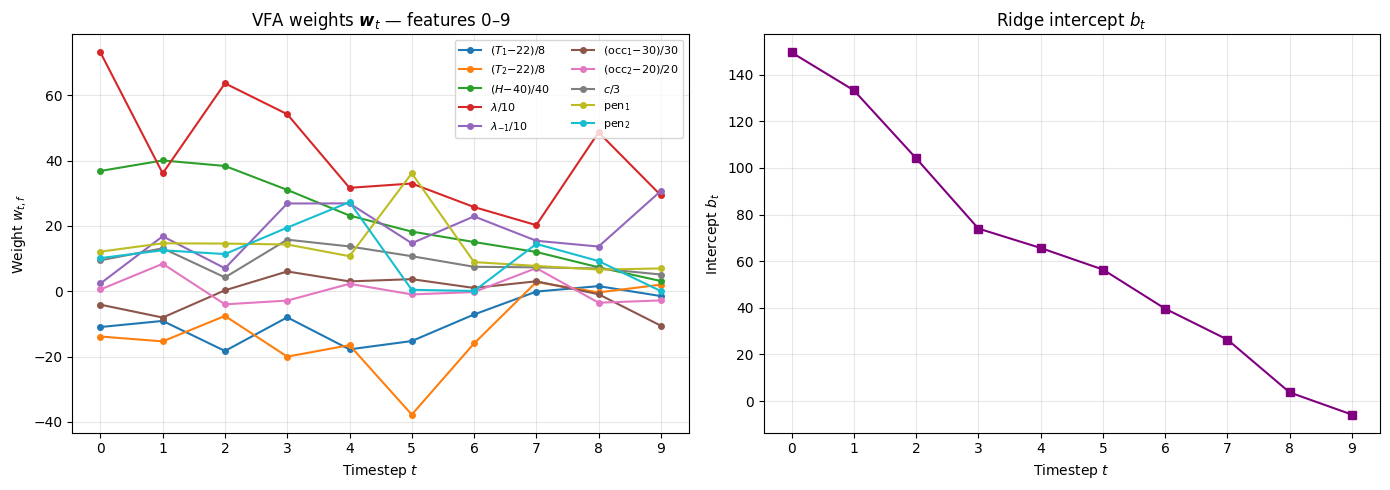

Saved: output/adp_weights_convergence.pdf


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ts   = np.arange(T)
lbls = ['$(T_1{-}22)/8$', '$(T_2{-}22)/8$', '$(H{-}40)/40$',
        '$\\lambda/10$', '$\\lambda_{-1}/10$',
        '$(\\mathrm{occ}_1{-}30)/30$', '$(\\mathrm{occ}_2{-}20)/20$', '$c/3$',
        '$\\mathrm{pen}_1$', '$\\mathrm{pen}_2$']
clr  = plt.cm.tab10(np.linspace(0, 0.9, N_FEAT))

for f in range(N_FEAT):
    ax1.plot(ts, eta_all[:T, f], marker='o', markersize=4,
             label=lbls[f], color=clr[f])
ax1.set_title('VFA weights $\\boldsymbol{w}_t$ — features 0–9')
ax1.set_xlabel('Timestep $t$')
ax1.set_ylabel('Weight $w_{t,f}$')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(ts)

ax2.plot(ts, eta_all[:T, N_FEAT], marker='s', color='purple')
ax2.set_title('Ridge intercept $b_t$')
ax2.set_xlabel('Timestep $t$')
ax2.set_ylabel('Intercept $b_t$')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(ts)

plt.tight_layout()
plt.savefig('output/adp_weights_convergence.pdf', bbox_inches='tight')
plt.show()
print("Saved: output/adp_weights_convergence.pdf")

## Verification

`ADP_policy_14.py` loads `output/adp_weights.json` at import time.
Running the cell below confirms the file is readable and the shapes are correct.

In [10]:
with open('output/adp_weights.json') as f:
    check = json.load(f)

print("JSON keys:", list(check.keys()))
print(f"Timesteps in 'eta': {sorted(check['eta'].keys())}")
print(f"Feature vector length: {len(check['eta']['0'])}")
print()
print("ADP_policy_14.py will load this file and call select_action(state)")
print("which runs solve_adp_step(state, ETA[t], params) for t = state['current_time'].")

JSON keys: ['description', 'feature_names', 'eta']
Timesteps in 'eta': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Feature vector length: 11

ADP_policy_14.py will load this file and call select_action(state)
which runs solve_adp_step(state, ETA[t], params) for t = state['current_time'].
